In [2]:
# Import Required Libraries
import os
import glob
import pymongo
import pandas as pd
import numpy as np
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import logging
from collections import defaultdict, Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

In [3]:
# Daten laden
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    return merged_df

merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

Gesamtdatensatz enthält 2000000 Einträge.


In [4]:
# Modelle gruppieren
model_paths = glob.glob('/ssd/v1/*.h5')

# Gruppierung nach Architektur, z.B. "create_model_1" extrahiert aus "create_model_1_samplesize_10000_negratio_0.5.h5"
model_groups = defaultdict(list)
for path in model_paths:
    filename = os.path.basename(path)
    parts = filename.split('_')
    if len(parts) >= 3:
        architecture = "_".join(parts[:3])  # ergibt z.B. "create_model_1"
    else:
        architecture = filename
    model_groups[architecture].append(path)

In [5]:
import tensorflow as tf

# Hilfsfunktionen
def load_model_from_path(model_path):
    return load_model(model_path)

def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # normalisieren
        return image_array
    except Exception as e:
        logging.error(f"Fehler bei der Bildverarbeitung: {e}")
        return None

def extract_images_from_df(df, usernames, sample_size=100):
    images = []
    labels = []
    for username in usernames:
        user_samples = df[df['username'] == username].sample(n=sample_size, random_state=42)
        for _, row in user_samples.iterrows():
            image = process_image_rgb(row['sampleData'])
            if image is not None:
                images.append(image)
                labels.append(username)
    return np.array(images), np.array(labels)

def predict_with_model(model, images):
    # Erzwinge Ausführung auf der CPU, um GPU-Probleme zu umgehen
    with tf.device('/CPU:0'):
        predictions = model.predict(images)
    # Bei binärer Klassifikation: als Score interpretieren
    return predictions.flatten()

def evaluate_model(model_path, df, usernames, sample_size=100):
    model = load_model_from_path(model_path)
    images, labels = extract_images_from_df(df, usernames, sample_size)
    predictions = predict_with_model(model, images)
    return predictions, labels

In [6]:
# Plot-Funktionen
def plot_predictions(predictions, labels, usernames, model_name, save_folder=None):
    plt.figure(figsize=(10, 5))
    for username in usernames:
        idx = [j for j, lab in enumerate(labels) if lab == username]
        if idx:
            plt.plot(predictions[idx], label=f'User {username}')
    plt.title(f'Predictions for {model_name}')
    plt.xlabel('Sample Index')
    plt.ylabel('Prediction Score')
    plt.legend()
    if save_folder:
        plt.savefig(os.path.join(save_folder, f"{model_name}_predictions.png"))
    plt.show()


def plot_false_predictions(false_predictions, false_positive_counter, target_user, model_name, save_folder=None):
    if false_predictions:
        plt.figure(figsize=(10, 5))
        users = [fp[0] for fp in false_predictions]
        preds = [fp[1] for fp in false_predictions]
        plt.scatter(users, preds, color='red', label='False Positives')
        plt.axhline(y=0.7, color='blue', linestyle='--', label='Threshold')
        plt.xlabel('Benutzer')
        plt.ylabel('Vorhersage-Score')
        plt.title('False Positives pro Benutzer')
        plt.legend()
        if save_folder:
            plt.savefig(os.path.join(
                save_folder, f"{model_name}false_predictions_scatter.png"))
        plt.show()

        # Pie-Chart
        fig2 = plt.figure(figsize=(8, 8))
        plt.pie(false_positive_counter.values(), labels=false_positive_counter.keys(),
                autopct='%1.1f%%', startangle=140)
        plt.title('Verteilung der False Positives (Nicht-target)')
        if save_folder:
            plt.savefig(os.path.join(save_folder, f"{model_name}false_predictions_pie.png"))
        plt.show()

        # Erstelle den Bar-Plot
        false_df = pd.DataFrame(list(false_positive_counter.items()),
                                columns=['Benutzer', 'False Positives'])
        # Umwandlung in numerische Daten erzwingen
        false_df['False Positives'] = pd.to_numeric(
            false_df['False Positives'], errors='coerce').fillna(0)
        if not false_df.empty and false_df['False Positives'].sum() > 0:
            fig3 = plt.figure(figsize=(8, 6))
            false_df.plot(kind='bar', x='Benutzer',
                          y='False Positives', legend=False, color='red')
            plt.title('False Positives pro Benutzer')
            plt.xlabel('Benutzer')
            plt.ylabel('Anzahl False Positives')
            if save_folder:
                plt.savefig(os.path.join(
                    save_folder, f"{model_name}false_predictions_bar.png"))
            plt.show()
        else:
            print("Keine numerischen Daten für False Positives zum Plotten vorhanden.")

        print("\nFalse Positives Table:")
        print(false_df)
    else:
        print("Keine False Positives zum Plotten vorhanden.")


def plot_metrics_table(metrics, model_name, save_folder=None):
    # Erstelle ein DataFrame aus dem metrics Dictionary ohne explizite Spaltenüberschriften
    metrics_df = pd.DataFrame(list(metrics.items()))
    fig, ax = plt.subplots(figsize=(6, len(metrics)*0.5 + 1))
    ax.axis('tight')
    ax.axis('off')
    # Kein Argument colLabels sorgt dafür, dass keine Überschriften angezeigt werden
    table = ax.table(cellText=metrics_df.values, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    plt.title("Metriken")
    if save_folder:
        plt.savefig(os.path.join(save_folder, f"{model_name}metrics_table.png"))
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name, save_folder=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    if save_folder:
        plt.savefig(os.path.join(save_folder, f"{model_name}confusion_matrix.png"))
    plt.show()

In [7]:
def extract_short_model_name(full_model_name):
    # Erwartete Struktur: "create_model_X_samplesize_Y_negratio_Z"
    parts = full_model_name.split('_')
    if len(parts) >= 7:
        # Extrahiere X, Y und Z
        return parts[2] + "_sample_" + parts[4] + "_" + parts[6]
    return full_model_name


In [8]:
# Evaluierungsfunktionen
def evaluate_predictions(predictions, labels, target_user, threshold=0.7):
    correct_predictions = 0
    total_predictions = len(labels)
    false_predictions = []  # (user, score) für Fehlklassifikationen
    false_positive_counter = Counter()
    target_user_recognized = 0

    y_true = []
    y_pred = []

    for pred, label in zip(predictions, labels):
        if label == target_user:
            y_true.append(1)
            if pred >= threshold:
                correct_predictions += 1
                target_user_recognized += 1
                y_pred.append(1)
            else:
                false_predictions.append((label, pred))  # False negative
                y_pred.append(0)
        else:
            y_true.append(0)
            if pred < threshold:
                correct_predictions += 1
                y_pred.append(0)
            else:
                false_predictions.append((label, pred))
                false_positive_counter[label] += 1
                y_pred.append(1)

    accuracy = correct_predictions / total_predictions
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, precision, recall, f1, false_predictions, dict(false_positive_counter), total_predictions, target_user_recognized, y_true, y_pred

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
# ... (weitere notwendige Importe, wie load_model, extract_images_from_df, etc.) ...

# Vor dem Main-Loop: Lade bestehende Ergebnisse aus der CSV
data_folder = os.path.expanduser("Data")
os.makedirs(data_folder, exist_ok=True)
results_file = os.path.join(data_folder, "evaluation_results.csv")
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    existing_results_df = pd.read_csv(results_file)
    existing_models = set(existing_results_df["Model"].tolist())
    print("Vorhandene Modelle:", existing_models)
else:
    existing_results_df = pd.DataFrame()
    existing_models = set()

results = []  # Liste für neu evaluierte Modelle

def extract_short_model_name(full_model_name):
    parts = full_model_name.split('_')
    if len(parts) >= 7:
        # Erwartete Struktur: "create_model_X_samplesize_Y_negratio_Z"
        return parts[2] + "_sample_" + parts[4] + "_" + parts[6]
    return full_model_name

def main():
    target_user = 'benutzername_1'
    usernames = merged_df['username'].unique()
    sample_size = 100

    # Lade oder initialisiere Notizen
    notes_path = os.path.expanduser("Data/notes.txt")
    os.makedirs(os.path.dirname(notes_path), exist_ok=True)
    if os.path.exists(notes_path):
        with open(notes_path, "r") as f:
            notes = f.read().splitlines()
    else:
        notes = []

    # Hauptschleife zur Evaluierung der Modelle, gruppiert nach Architektur
    for architecture, paths in model_groups.items():
        base_folder = os.path.expanduser("Pictures")
        arch_folder = os.path.join(base_folder, architecture)
        os.makedirs(arch_folder, exist_ok=True)
        
        for model_path in paths:
            model_name = os.path.splitext(os.path.basename(model_path))[0]
            full_model_name = model_name  # Guter Schlüssel für den Vergleich
            short_model_name = extract_short_model_name(full_model_name)
            
            # Überspringe Modelle, die bereits evaluiert wurden (überprüft anhand der CSV)
            if short_model_name in existing_models:
                print(f"Modell {full_model_name} wurde bereits evaluiert, überspringe.")
                continue

            print(f"\nEvaluating model: {full_model_name}")
            predictions, labels = evaluate_model(model_path, merged_df, usernames, sample_size)
            # Füge model_name als letzten Parameter hinzu
            plot_predictions(predictions, labels, usernames, model_name=short_model_name, save_folder=arch_folder)
            accuracy, precision, recall, f1, false_predictions, false_positive_counter, total_preds, target_recognized, y_true, y_pred = evaluate_predictions(predictions, labels, target_user)
            
            total_target_evaluated = sum(1 for label in labels if label == target_user)
            print(f"Erkannt für {target_user}: {target_recognized} von {total_target_evaluated}")

            plot_false_predictions(false_predictions, false_positive_counter, target_user, model_name=short_model_name, save_folder=arch_folder)
            plot_confusion_matrix(y_true, y_pred, save_folder=arch_folder, model_name=short_model_name)

            total_false = sum(false_positive_counter.values())
            metrics = {
                "Model": short_model_name,
                "Accuracy": f"{accuracy:.2f}",
                "Precision": f"{precision:.2f}",
                "Recall": f"{recall:.2f}",
                "F1 Score": f"{f1:.2f}",
                "Total Predictions": total_preds,
                f"Recognized as {target_user}": f"{target_recognized} von {total_target_evaluated}",
                "Total False Positives": total_false
            }
            results.append(metrics)
            plot_metrics_table(metrics, save_folder=arch_folder, model_name=short_model_name)
            print(f"Evaluation completed for model: {full_model_name} with accuracy: {accuracy:.2f}")

            # Append: Schreibe das Ergebnis als neue Zeile in die CSV-Datei (ohne Überschreiben)
            new_results_df = pd.DataFrame([metrics])
            with open(results_file, "a") as f:
                # Schreibe den Header nur, wenn die Datei leer ist.
                new_results_df.to_csv(f, index=False, header=f.tell()==0)
            # Aktualisiere das Set der evaluierten Modelle, damit sie beim nächsten Durchlauf übersprungen werden
            existing_models.add(full_model_name)
    
    # Für weitere Auswertungen: Lies die gesamte CSV erneut ein
    combined_df = pd.read_csv(results_file)
    print("Kombinierte Ergebnisse gespeichert:", results_file)
    
    best_models = combined_df.sort_values(by="F1 Score", ascending=False).head(5)
    print("\nBeste 5 Modelle basierend auf dem F1-Score:")
    print(best_models)

    best_models.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar", figsize=(10, 6))
    plt.title("Beste 5 Modelle basierend auf dem F1-Score")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.legend(loc="best")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(data_folder, "best_models_comparison.png"))
    plt.show()

    combined_df.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar", figsize=(15, 8))
    plt.title("Vergleich der Modelle basierend auf Accuracy, Precision, Recall und F1 Score")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.legend(loc="best")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(data_folder, "all_models_comparison.png"))
    plt.show()

    # Erstelle bzw. setze den Ordner für die Analysebilder
    images_folder = os.path.join(data_folder, "analysis_images")
    os.makedirs(images_folder, exist_ok=True)

    # Konvertiere numerische Spalten
    numeric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "Total Predictions", "Total False Positives"]
    for col in numeric_cols:
        combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")

    # Extrahiere die Recognized Ratio aus der Spalte "Recognized as benutzername_1" (Format: "100 von 100")
    def parse_recognized(x):
        try:
            recognized, total = x.split(" von ")
            return int(recognized) / int(total)
        except Exception:
            return None

    combined_df["Recognized_Ratio"] = combined_df[f"Recognized as {target_user}"].apply(parse_recognized)

    # 1. Beste 5 Modelle basierend auf dem F1 Score (Balkendiagramm)
    best_models = combined_df.sort_values("F1 Score", ascending=False).head(5)
    plt.figure(figsize=(10, 6))
    best_models.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar", ax=plt.gca())
    plt.title("Beste 5 Modelle basierend auf dem F1-Score")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(images_folder, "best_models_comparison.png"))
    plt.close()

    # 2. Vergleich aller Modelle (Balkendiagramm)
    plt.figure(figsize=(15, 8))
    combined_df.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar", ax=plt.gca())
    plt.title("Vergleich der Modelle: Accuracy, Precision, Recall und F1 Score")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(images_folder, "all_models_comparison.png"))
    plt.close()

    # 3. Top 10 Modelle – Performance Metriken gruppiert (Balkendiagramm für einzelne Metriken)
    top10 = combined_df.sort_values("F1 Score", ascending=False).head(10)
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    x = range(len(top10))
    width = 0.2
    plt.figure(figsize=(15, 8))
    for i, metric in enumerate(metrics):
        plt.bar([p + i * width for p in x], top10[metric], width=width, label=metric)
    plt.xticks([p + 1.5 * width for p in x], top10["Model"], rotation=45, ha="right")
    plt.xlabel("Modelle")
    plt.ylabel("Score")
    plt.title("Top 10 Modelle – Performance Metriken")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(images_folder, "top10_performance_metrics.png"))
    plt.close()

    # 4. Scatter-Plot: Total Predictions vs. Total False Positives
    plt.figure(figsize=(10, 6))
    plt.scatter(combined_df["Total Predictions"], combined_df["Total False Positives"], alpha=0.7, c="coral")
    plt.xlabel("Total Predictions")
    plt.ylabel("Total False Positives")
    plt.title("Total Predictions vs. Total False Positives")
    plt.tight_layout()
    plt.savefig(os.path.join(images_folder, "predictions_vs_false.png"))
    plt.close()

    # 5. Balkendiagramm: Erkennungsquote (Recognized Ratio) aller Modelle
    df_sorted = combined_df.sort_values("Recognized_Ratio", ascending=False)
    plt.figure(figsize=(12, 6))
    plt.bar(df_sorted["Model"], df_sorted["Recognized_Ratio"], color="seagreen")
    plt.xticks(rotation=90)
    plt.ylabel("Recognized Ratio")
    plt.title("Erkennungsquote der Modelle (Erkannt/Total)")
    plt.tight_layout()
    plt.savefig(os.path.join(images_folder, "recognized_ratio.png"))
    plt.close()



Vorhandene Modelle: {'3_sample_5000_1', '3_sample_1000_1', '5_sample_2000_2', '5_sample_5000_1', '3_sample_10000_1', '5_sample_10000_0.5', '5_sample_1000_1', '1_sample_500_1', '2_sample_5000_1', '2_sample_1000_1', '4_sample_500_0.5', '5_sample_100_2', '3_sample_100_2', '2_sample_100_1', '3_sample_10000_2', '1_sample_200_1', '3_sample_200_2', '5_sample_10000_1', '1_sample_200_0.5', '3_sample_2000_1', '1_sample_100_0.5', '5_sample_500_2', '5_sample_200_2', '5_sample_5000_2', '3_sample_200_1', '4_sample_500_1', '2_sample_200_2', '1_sample_5000_1', '4_sample_1000_1', '3_sample_1000_0.5', '2_sample_200_1', '5_sample_200_1', '3_sample_500_0.5', '2_sample_10000_2', '1_sample_10000_0.5', '5_sample_1000_0.5', '4_sample_2000_0.5', '4_sample_5000_2', '5_sample_2000_1', '3_sample_500_2', '1_sample_1000_0.5', '1_sample_5000_2', '1_sample_1000_1', '5_sample_100_0.5', '2_sample_1000_2', '4_sample_100_0.5', '4_sample_200_2', '5_sample_10000_2', '4_sample_10000_0.5', '4_sample_5000_1', '3_sample_1000_2

In [10]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth for all detected GPUs (z.B. 2 GPUs)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"{len(gpus)} GPUs detected; memory growth set for each.")
    except RuntimeError as e:
        print(e)
else:
    print("Keine GPUs gefunden.")

1 GPUs detected; memory growth set for each.


2025-02-06 14:56:46.818604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-06 14:56:46.863401: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-06 14:56:46.863711: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [ ]:
if __name__ == "__main__":
    main()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Pfad zur CSV-Datei
data_folder = os.path.expanduser("Data")
results_file = os.path.join(data_folder, "evaluation_results.csv")
df = pd.read_csv(results_file)

# Konvertiere Spalten in numerische Werte
numeric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "Total Predictions", "Total False Positives"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Extrahiere den Anteil der erkannten Beispiele aus der Spalte "Recognized as benutzername_1" (z.B. "100 von 100")
def parse_recognized(x):
    try:
        recognized, total = x.split(" von ")
        return int(recognized) / int(total)
    except:
        return None

df["Recognized_Ratio"] = df["Recognized as benutzername_1"].apply(parse_recognized)

# 1. Balkendiagramm: Top 10 Modelle (nach F1 Score) und ihre Performance-Metriken
top10 = df.sort_values("F1 Score", ascending=False).head(10)
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()
for i, metric in enumerate(metrics):
    axs[i].bar(top10["Model"], top10[metric], color="skyblue")
    axs[i].set_title(metric)
    axs[i].set_xticklabels(top10["Model"], rotation=45, ha="right")
    axs[i].set_ylim(0, 1)
fig.suptitle("Top 10 Modelle – Performance Metriken", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(data_folder, "top10_performance_metrics.png"))
plt.show()

# 2. Scatter-Plot: Total Predictions vs. Total False Positives
plt.figure(figsize=(10, 6))
plt.scatter(df["Total Predictions"], df["Total False Positives"], alpha=0.7, c='coral')
plt.xlabel("Total Predictions")
plt.ylabel("Total False Positives")
plt.title("Total Predictions vs. Total False Positives")
plt.tight_layout()
plt.savefig(os.path.join(data_folder, "predictions_vs_false.png"))
plt.show()

# 3. Balkendiagramm: Erkennungsquote (Recognized Ratio) aller Modelle
df_sorted = df.sort_values("Recognized_Ratio", ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(df_sorted["Model"], df_sorted["Recognized_Ratio"], color="seagreen")
plt.xticks(rotation=90)
plt.ylabel("Recognized Ratio")
plt.title("Erkennungsquote der Modelle (Erkannt/Total)")
plt.tight_layout()
plt.savefig(os.path.join(data_folder, "recognized_ratio.png"))
plt.show()


In [13]:
import shutil
import os

folder = "gesamtergebnisse"

if os.path.exists(folder):
    shutil.rmtree(folder)
    print(f"Ordner '{folder}' wurde gelöscht.")
else:
    print(f"Ordner '{folder}' existiert nicht.")

Ordner 'gesamtergebnisse' wurde gelöscht.


In [14]:
import pandas as pd

def restore_full_model_name(short_name):
    parts = short_name.split('_')
    # Beispiel: "5_sample_5000_2" -> "create_model_5_samplesize_5000_negratio_2.h5"
    if len(parts) == 4 and parts[1] == "sample":
        return f"create_model_{parts[0]}_samplesize_{parts[2]}_negratio_{parts[3]}.h5"
    return short_name

def extract_architecture(full_model_name):
    parts = full_model_name.split('_')
    # Vorher: f"{parts[0]}_{parts[1]}" ergab für jeden "create_model"
    # Jetzt nehmen wir auch den dritten Teil, um z. B. "create_model_5" zu erhalten.
    if len(parts) >= 3:
        return f"{parts[0]}_{parts[1]}_{parts[2]}"
    return full_model_name

# Lade die Performance-Daten
data_folder = "Data"
results_file = f"{data_folder}/evaluation_results.csv"
results_df = pd.read_csv(results_file)

# Konvertiere numerische Spalten in Zahlen
numeric_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]
results_df[numeric_cols] = results_df[numeric_cols].apply(pd.to_numeric)

# Wiederherstellung des vollständigen Modellnamens und Ermittlung der Architektur
results_df["FullModelName"] = results_df["Model"].apply(restore_full_model_name)
results_df["Architecture"] = results_df["FullModelName"].apply(extract_architecture)

# Gruppiere nach Architektur (z.B. create_model_1, create_model_2, ...) 
# und finde das Modell mit dem höchsten F1 Score je Gruppe.
best_models = {}
for arch, group in results_df.groupby("Architecture"):
    best_row = group.loc[group["F1 Score"].idxmax()]
    best_models[arch] = {
        "FullModelName": best_row["FullModelName"],
        "F1 Score": best_row["F1 Score"]
    }

print("Beste Modelle je Architektur:")
for arch, info in best_models.items():
    print(f"{arch}: {info['FullModelName']} mit F1 Score {info['F1 Score']}")

Beste Modelle je Architektur:
create_model_1: create_model_1_samplesize_100_negratio_2.h5 mit F1 Score 0.56
create_model_2: create_model_2_samplesize_5000_negratio_0.5.h5 mit F1 Score 0.41
create_model_3: create_model_3_samplesize_5000_negratio_0.5.h5 mit F1 Score 0.4
create_model_4: create_model_4_samplesize_5000_negratio_1.h5 mit F1 Score 0.4
create_model_5: create_model_5_samplesize_2000_negratio_1.h5 mit F1 Score 0.42


In [15]:
# Imports und Helper-Funktionen
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import precision_score

def restore_full_model_name(short_name):
    parts = short_name.split('_')
    # Beispiel: "5_sample_5000_2" -> "create_model_5_samplesize_5000_negratio_2.h5"
    if len(parts) == 4 and parts[1] == "sample":
        return f"create_model_{parts[0]}_samplesize_{parts[2]}_negratio_{parts[3]}.h5"
    return short_name

def find_model_path(full_model_name, model_paths):
    for path in model_paths:
        if os.path.basename(path) == full_model_name:
            return path
    return None

def extract_architecture(full_model_name):
    parts = full_model_name.split('_')
    # Beispiel: "create_model_5_samplesize_5000_negratio_2.h5" -> "create_model_5"
    if len(parts) >= 3:
        return f"{parts[0]}_{parts[1]}_{parts[2]}"
    return full_model_name

# Daten laden und vorbereiten
model_paths = glob.glob('/ssd/v1/*.h5')
if not model_paths:
    print("Keine Modelle in /ssd/v1/ gefunden.")

data_folder = os.path.expanduser("Data")
results_file = os.path.join(data_folder, "evaluation_results.csv")
results_df = pd.read_csv(results_file)
numeric_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]
results_df[numeric_cols] = results_df[numeric_cols].apply(pd.to_numeric)

# Auswahl global bester 5 Modelle (basierend auf F1 Score)
best_models = results_df.sort_values(by="F1 Score", ascending=False).head(5)
print("Beste 5 Modelle (gekürzte Namen aus CSV):")
print(best_models)

# Merged-Daten laden (load_data() muss vorher definiert sein)
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")
usernames = merged_df["username"].unique()

Beste 5 Modelle (gekürzte Namen aus CSV):
               Model  Accuracy  Precision  Recall  F1 Score  \
36    1_sample_100_2      0.93       0.42    0.86      0.56   
34    1_sample_200_2      0.92       0.37    0.89      0.52   
30    1_sample_500_2      0.90       0.33    0.90      0.48   
33  1_sample_10000_2      0.89       0.30    0.95      0.46   
24   1_sample_1000_1      0.87       0.28    0.99      0.44   

    Total Predictions Recognized as benutzername_1  Total False Positives  
36               2000                   86 von 100                    121  
34               2000                   89 von 100                    154  
30               2000                   90 von 100                    182  
33               2000                   95 von 100                    221  
24               2000                   99 von 100                    253  
Gesamtdatensatz enthält 2000000 Einträge.


(Global) Lade Modell create_model_1_samplesize_100_negratio_2.h5 von /ssd/v1/create_model_1_samplesize_100_negratio_2.h5
1/1 [==============================] - 0s 15ms/step
(Global) Lade Modell create_model_1_samplesize_200_negratio_2.h5 von /ssd/v1/create_model_1_samplesize_200_negratio_2.h5
1/1 [==============================] - 0s 34ms/step
(Global) Lade Modell create_model_1_samplesize_500_negratio_2.h5 von /ssd/v1/create_model_1_samplesize_500_negratio_2.h5
1/1 [==============================] - 0s 14ms/step
(Global) Lade Modell create_model_1_samplesize_10000_negratio_2.h5 von /ssd/v1/create_model_1_samplesize_10000_negratio_2.h5
1/1 [==============================] - 0s 13ms/step
(Global) Lade Modell create_model_1_samplesize_1000_negratio_1.h5 von /ssd/v1/create_model_1_samplesize_1000_negratio_1.h5
1/1 [==============================] - 0s 14ms/step
Bild gespeichert unter: prediction_confidence_global_top5.png


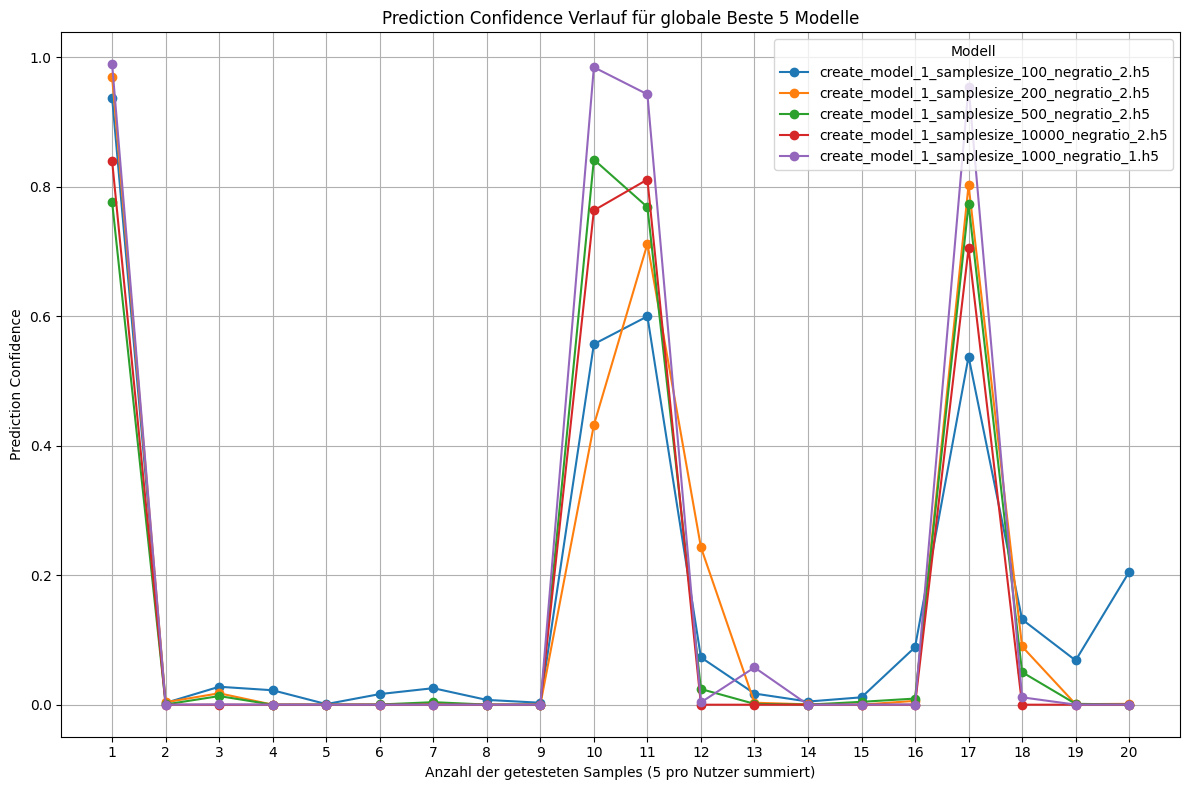

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_score

global_precision = {}
global_sample_details = {}
global_confidences = {}

plt.figure(figsize=(12,8))
for _, row in best_models.iterrows():
    short_model_name = row["Model"]
    full_model_name = restore_full_model_name(short_model_name)
    model_path = find_model_path(full_model_name, model_paths)
    if not model_path:
        print(f"(Global) Kein Dateipfad für {full_model_name} gefunden.")
        continue
    print(f"(Global) Lade Modell {full_model_name} von {model_path}")
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"(Global) Fehler beim Laden des Modells {full_model_name}: {e}")
        continue

    global_precision[full_model_name] = {}
    global_sample_details[full_model_name] = {}
    confidences_collect = []  # Zwischenspeicher für aggregierte Confidence-Werte

    for user in usernames:
        user_df = merged_df[merged_df["username"] == user]
        if len(user_df) < 5:
            continue
        sample_user_df = user_df.sample(n=5, random_state=42)
        global_sample_details[full_model_name][user] = sample_user_df.index.tolist()
        images_user, true_labels_user = extract_images_from_df(merged_df, [user], sample_size=5)
        try:
            with tf.device('/GPU:0'):
                preds = model.predict(images_user)
        except Exception:
            with tf.device('/CPU:0'):
                preds = model.predict(images_user)
        preds = preds.flatten()
        
        # Aggregiere die 5 Prediction Confidence-Werte zu einem Mittelwert
        avg_confidence = np.mean(preds)
        confidences_collect.append(avg_confidence)
        
        pred_labels = (preds >= 0.5).astype(int)
        true_binary = (np.array(true_labels_user) == user).astype(int)
        prec = precision_score(true_binary, pred_labels, zero_division=0)
        
        global_precision[full_model_name][user] = prec

    global_confidences[full_model_name] = confidences_collect
    # X-Achse startet jetzt bei 1 und geht in 1er-Schritten bis zur Anzahl der Werte
    plt.plot(range(1, len(confidences_collect)+1), confidences_collect, marker='o', label=full_model_name)
    
plt.xlabel("Anzahl der getesteten Samples (5 pro Nutzer summiert)")
plt.ylabel("Prediction Confidence")
plt.title("Prediction Confidence Verlauf für globale Beste 5 Modelle")
plt.legend(title="Modell", loc="upper right")
plt.grid(True)
plt.tight_layout()

# Setze explizit die xticks, sodass ab 1 in 1er-Schritten (bis max. Länge) nummeriert wird
max_samples = max(len(c) for c in global_confidences.values())
plt.xticks(range(1, max_samples+1))

# Speichern unter dem gewünschten Dateinamen
save_filename = "prediction_confidence_global_top5.png"
plt.savefig(save_filename, bbox_inches="tight")
print(f"Bild gespeichert unter: {save_filename}")
plt.show()


Bestes Modell je Architektur (1-5):
{'create_model_5': 'create_model_5_samplesize_2000_negratio_1.h5', 'create_model_1': 'create_model_1_samplesize_100_negratio_2.h5', 'create_model_4': 'create_model_4_samplesize_5000_negratio_1.h5', 'create_model_3': 'create_model_3_samplesize_5000_negratio_0.5.h5', 'create_model_2': 'create_model_2_samplesize_5000_negratio_0.5.h5'}
(Arch) Lade Modell create_model_5_samplesize_2000_negratio_1.h5 von /ssd/v1/create_model_5_samplesize_2000_negratio_1.h5
1/1 [==============================] - 0s 14ms/step
(Arch) Lade Modell create_model_1_samplesize_100_negratio_2.h5 von /ssd/v1/create_model_1_samplesize_100_negratio_2.h5
1/1 [==============================] - 0s 14ms/step
(Arch) Lade Modell create_model_4_samplesize_5000_negratio_1.h5 von /ssd/v1/create_model_4_samplesize_5000_negratio_1.h5
1/1 [==============================] - 0s 14ms/step
(Arch) Lade Modell create_model_3_samplesize_5000_negratio_0.5.h5 von /ssd/v1/create_model_3_samplesize_5000_neg

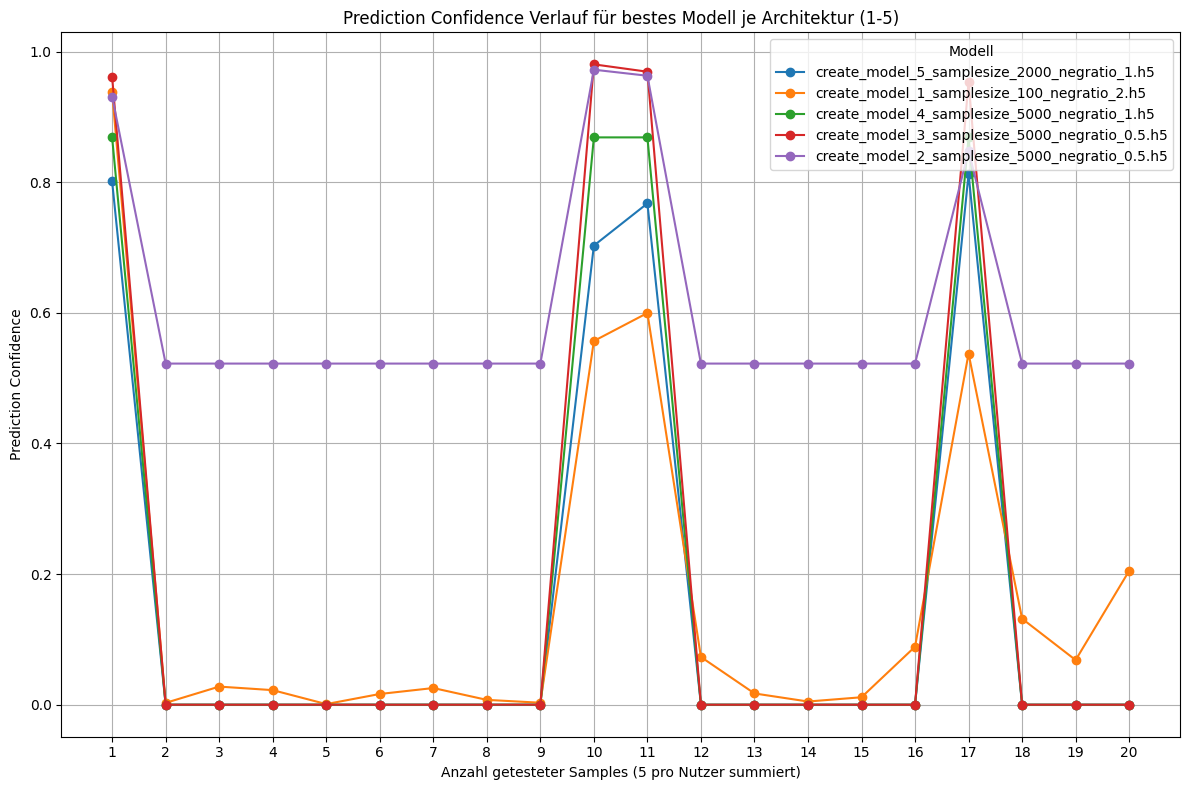

In [41]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import precision_score

# Ermitteln des besten Modells je Architektur
arch_model_dict = {}
for _, row in results_df.iterrows():
    short_model_name = row["Model"]
    full_model_name = restore_full_model_name(short_model_name)
    arch = extract_architecture(full_model_name)
    if arch in [f"create_model_{i}" for i in range(1, 6)]:
        arch_model_dict.setdefault(arch, []).append((full_model_name, row["F1 Score"]))

best_per_arch = {}
for arch, models in arch_model_dict.items():
    best_model = max(models, key=lambda x: x[1])[0]
    best_per_arch[arch] = best_model
print("\nBestes Modell je Architektur (1-5):")
print(best_per_arch)

arch_precision = {}
arch_sample_details = {}
arch_confidences = {}

plt.figure(figsize=(12, 8))
for arch, full_model_name in best_per_arch.items():
    model_path = find_model_path(full_model_name, model_paths)
    if not model_path:
        print(f"(Arch) Kein Dateipfad für {full_model_name} gefunden.")
        continue
    print(f"(Arch) Lade Modell {full_model_name} von {model_path}")
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"(Arch) Fehler beim Laden des Modells {full_model_name}: {e}")
        continue

    arch_precision[full_model_name] = {}
    arch_sample_details[full_model_name] = {}
    conf_collect = []  # Zwischenspeicher für aggregierte Confidence-Werte

    for user in usernames:
        user_df = merged_df[merged_df["username"] == user]
        if len(user_df) < 5:
            continue
        sample_user_df = user_df.sample(n=5, random_state=42)
        arch_sample_details[full_model_name][user] = sample_user_df.index.tolist()
        images_user, true_labels_user = extract_images_from_df(merged_df, [user], sample_size=5)
        try:
            with tf.device('/GPU:0'):
                preds = model.predict(images_user)
        except Exception:
            with tf.device('/CPU:0'):
                preds = model.predict(images_user)
        preds = preds.flatten()

        avg_confidence = np.mean(preds)
        conf_collect.append(avg_confidence)

        pred_labels = (preds >= 0.5).astype(int)
        true_binary = (np.array(true_labels_user) == user).astype(int)
        prec = precision_score(true_binary, pred_labels, zero_division=0)

        arch_precision[full_model_name][user] = prec

    arch_confidences[full_model_name] = conf_collect
    # X-Achse ab 1 nummerieren
    plt.plot(range(1, len(conf_collect) + 1), conf_collect, marker='o', label=full_model_name)

plt.xlabel("Anzahl getesteter Samples (5 pro Nutzer summiert)")
plt.ylabel("Prediction Confidence")
plt.title("Prediction Confidence Verlauf für bestes Modell je Architektur (1-5)")
plt.legend(title="Modell", loc="upper right")
plt.grid(True)
plt.tight_layout()
# Setze X-Ticks ab 1 in 1-Schritten
max_samples_arch = max(len(c) for c in arch_confidences.values())
plt.xticks(range(1, max_samples_arch + 1))
plt.savefig("prediction_confidence_best_architecture.png", bbox_inches="tight")
plt.show()

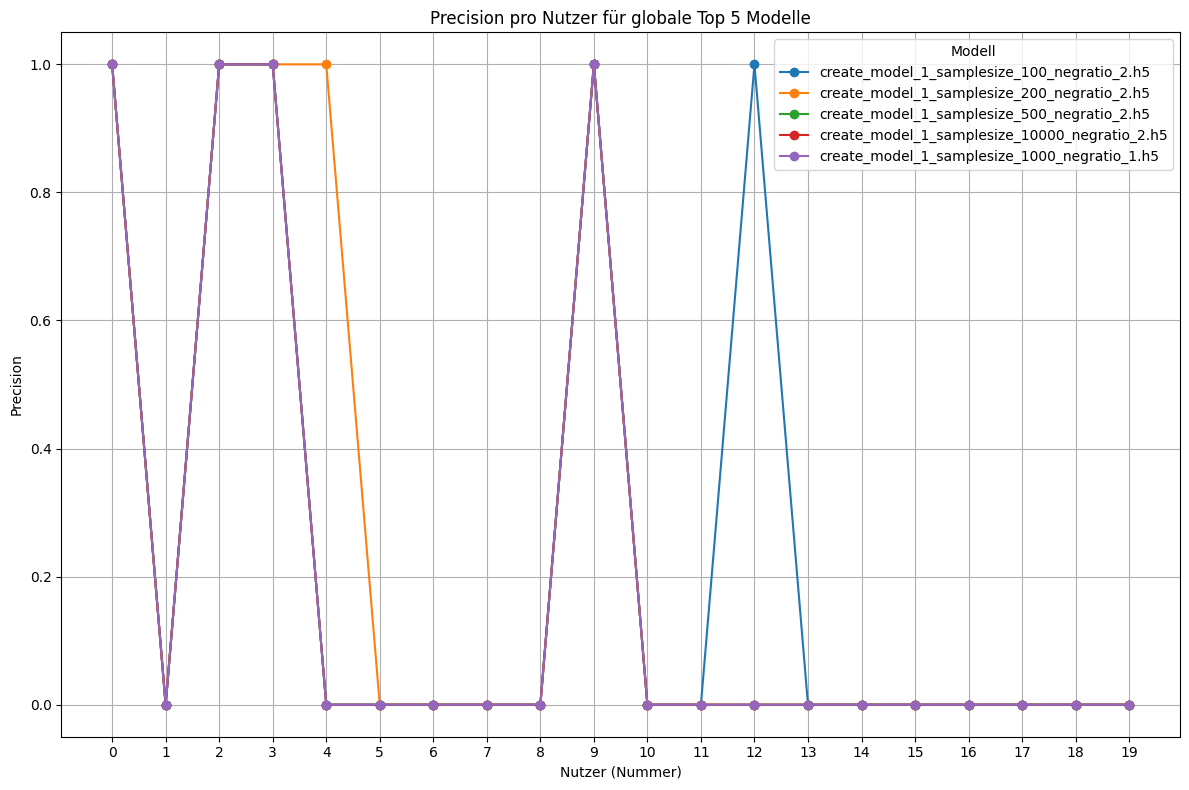

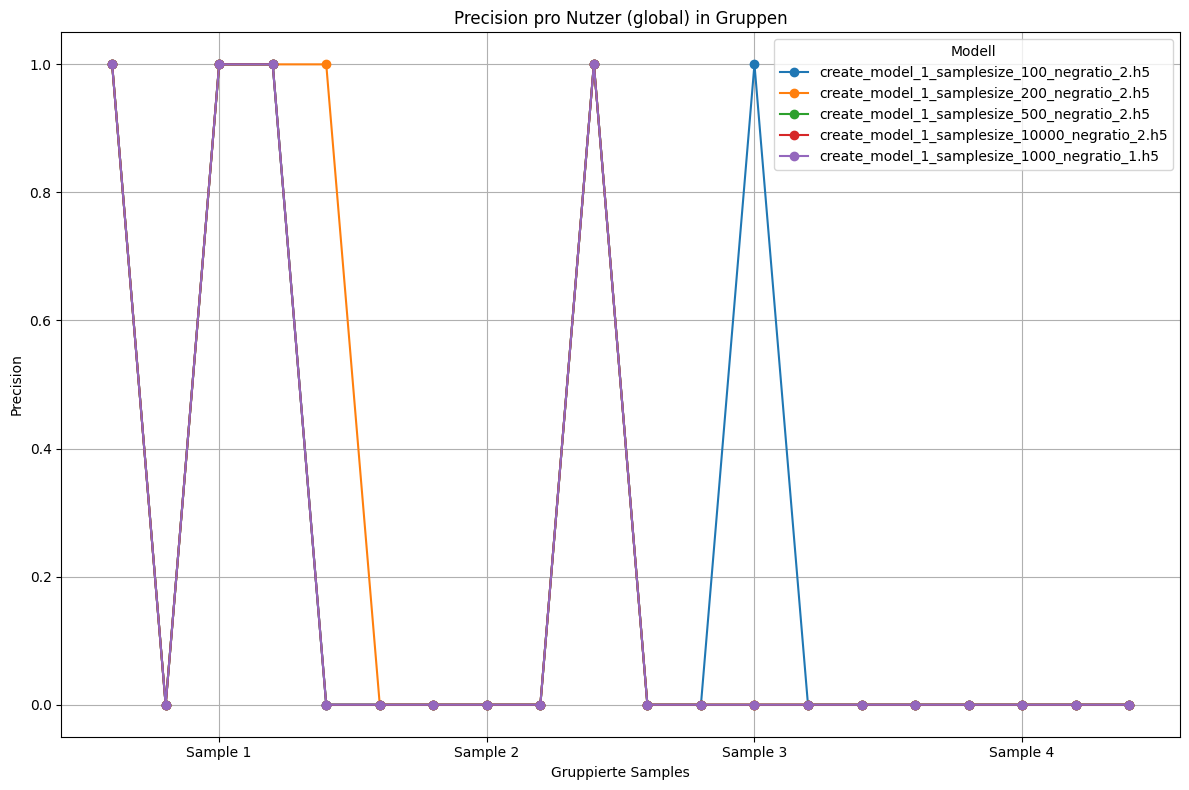

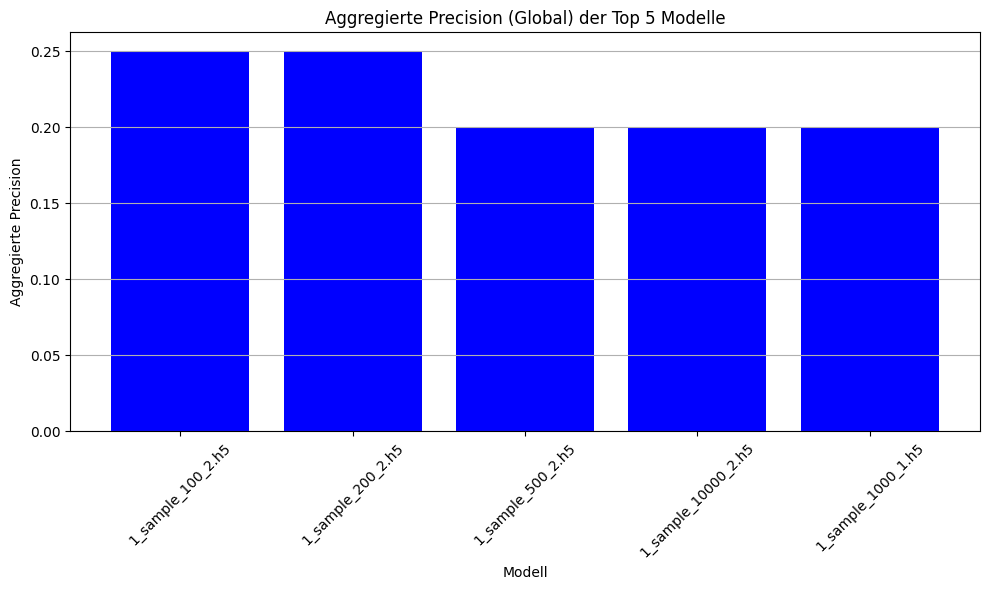

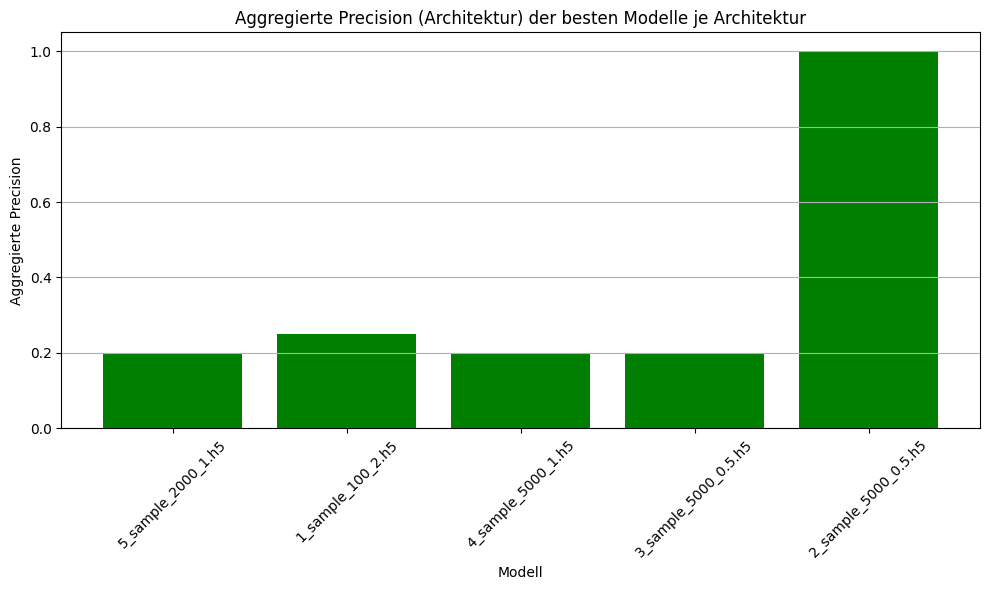

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Beispiel: Global – Precision pro Nutzer (X-Achse: Nutzer als Nummern)
plt.figure(figsize=(12,8))
for model_name, user_prec in global_precision.items():
    users = sorted(user_prec.keys())
    user_indices = list(range(len(users)))
    prec_values = [user_prec[u] for u in users]
    plt.plot(user_indices, prec_values, marker='o', label=model_name)
plt.xlabel("Nutzer (Nummer)")
plt.ylabel("Precision")
plt.title("Precision pro Nutzer für globale Top 5 Modelle")
plt.xticks(user_indices)
plt.legend(title="Modell", loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig("global_precision_nutzer.png", bbox_inches="tight")
plt.show()

# Funktion für gruppierte X-Ticks
def set_grouped_xticks(num_points, group_size=5):
    num_groups = int(np.ceil(num_points / group_size))
    positions = []
    labels = []
    for g in range(num_groups):
        start = g * group_size
        end = min((g + 1) * group_size, num_points)
        mid = (start + end - 1) / 2.0
        positions.append(mid)
        labels.append(f"Sample {g+1}")
    return positions, labels

# Global Precision Plot mit gruppierter X-Achse
plt.figure(figsize=(12,8))
for model_name, user_prec in global_precision.items():
    users = sorted(user_prec.keys())
    num_points = len(users)
    user_indices = list(range(num_points))
    prec_values = [user_prec[u] for u in users]
    plt.plot(user_indices, prec_values, marker='o', label=model_name)

positions, labels = set_grouped_xticks(num_points, group_size=5)
plt.xticks(positions, labels)
plt.xlabel("Gruppierte Samples")
plt.ylabel("Precision")
plt.title("Precision pro Nutzer (global) in Gruppen")
plt.legend(title="Modell", loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig("global_precision_nutzer_grouped.png", bbox_inches="tight")
plt.show()

# Aggregierte Precision (pro Modell über alle Nutzer)
aggregated_global_precision = {}
for model_name, user_prec in global_precision.items():
    values = list(user_prec.values())
    aggregated_global_precision[model_name] = np.mean(values) if values else np.nan

plt.figure(figsize=(10,6))
# Extract shortened model names using extract_short_model_name function
models = [extract_short_model_name(os.path.basename(model)) for model in aggregated_global_precision.keys()]
values = list(aggregated_global_precision.values())
plt.bar(models, values, color="blue")
plt.xlabel("Modell")
plt.ylabel("Aggregierte Precision")
plt.title("Aggregierte Precision (Global) der Top 5 Modelle")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("aggregated_precision_global.png", bbox_inches="tight")
plt.show()

# Analog: Aggregierte Precision für Architektur
aggregated_arch_precision = {}
for model_name, user_prec in arch_precision.items():
    values = list(user_prec.values())
    aggregated_arch_precision[model_name] = np.mean(values) if values else np.nan

plt.figure(figsize=(10,6))
models_arch = [extract_short_model_name(os.path.basename(model)) for model in aggregated_arch_precision.keys()]
values_arch = list(aggregated_arch_precision.values())
plt.bar(models_arch, values_arch, color="green")
plt.xlabel("Modell")
plt.ylabel("Aggregierte Precision")
plt.title("Aggregierte Precision (Architektur) der besten Modelle je Architektur")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("aggregated_precision_architecture.png", bbox_inches="tight")
plt.show()

In [37]:
import shutil
import os

pictures_path = os.path.expanduser("Pictures")

if os.path.exists(pictures_path):
    shutil.rmtree(pictures_path)
    print(f"Ordner '{pictures_path}' wurde gelöscht.")
else:
    print(f"Ordner '{pictures_path}' existiert nicht.")

Ordner 'Pictures' existiert nicht.


In [ ]:
data_path = os.path.expanduser("Data")

if os.path.exists(data_path):
    shutil.rmtree(data_path)
    print(f"Ordner '{data_path}' wurde gelöscht.")
else:
    print(f"Ordner '{data_path}' existiert nicht.")

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics_table(metrics, model_name, save_folder=None):
    # Erstelle ein DataFrame der Metriken
    metrics_df = pd.DataFrame(list(metrics.items()))
    fig, ax = plt.subplots(figsize=(6, len(metrics)*0.5 + 1))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=metrics_df.values, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    plt.title(f"Metriken - {model_name}")
    if save_folder:
        file_path = os.path.join(save_folder, f"{model_name}_metrics_table.png")
        plt.savefig(file_path)
    plt.show()

# Lade die vorhandenen Evaluationsergebnisse aus der CSV
data_folder = os.path.expanduser("Data")
results_file = os.path.join(data_folder, "evaluation_results.csv")
results_df = pd.read_csv(results_file)

# Erstelle einen Unterordner zum Speichern der Metriken-Tabellen, falls nicht vorhanden
metrics_folder = os.path.join(data_folder, "metrics_tables")
os.makedirs(metrics_folder, exist_ok=True)

# Iteriere über alle Zeilen in der CSV und erzeuge für jedes Modell eine eigene Metriken-Tabelle
for _, row in results_df.iterrows():
    # Konvertiere die Zeile in ein Dictionary; so bleiben auch Spaltennamen erhalten,
    # z.B. "Recognized as benutzername_1"
    metrics = row.to_dict()
    # Entnimm den Modellnamen aus der "Model"-Spalte
    model_name = metrics["Model"]
    # Erstelle die Metriken-Tabelle für dieses Modell
    plot_metrics_table(metrics, model_name, save_folder=metrics_folder)